In [1]:
import sys
sys.path.append("..")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
from src.split import chronological_split, get_X_y, scale_features_and_target
from src.models.gru_model import create_sequences, train_gru
 
df_feat = pd.read_csv("../data_processed/ETHUSDT_features.csv", parse_dates=["open_time"])
df_feat.set_index("open_time", inplace=True)
 
train, test = chronological_split(df_feat, test_ratio=0.2)
print(f"Train: {len(train)} satır, Test: {len(test)} satır")
 
 

Train: 13988 satır, Test: 3498 satır


In [2]:
# --- Hücre 2: feature/target ayrımı (getiri bazlı hedef) ---
feature_cols = [c for c in df_feat.columns if c not in ["open", "high", "low", "close", "target", "target_return"]]
 
X_train, y_train = get_X_y(train, feature_cols, target_col="target_return")
X_test, y_test = get_X_y(test, feature_cols, target_col="target_return")
 
print(X_train.shape, X_test.shape)
print(feature_cols)

(13988, 17) (3498, 17)
['volume', 'rsi', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'atr', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']


In [3]:

# --- Hücre 3: scale et ---
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, x_scaler, y_scaler = scale_features_and_target(
    X_train, X_test, y_train, y_test
)
 

In [4]:

# --- Hücre 4: sliding window + GRU eğitimi ---
WINDOW = 30
 
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window=WINDOW)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window=WINDOW)
 
print(X_train_seq.shape, X_test_seq.shape)
 
model_gru, train_losses, test_losses = train_gru(
    X_train_seq, y_train_seq, X_test_seq, y_test_seq,
    input_size=X_train_seq.shape[2],
    epochs=50,
    lr=5e-4
)
 

(13958, 30, 17) (3468, 30, 17)
Kullanılan cihaz: cuda
Epoch 5/50 - Train Loss: 1.002202 - Test Loss: 0.663700
Epoch 10/50 - Train Loss: 1.001450 - Test Loss: 0.669847
Epoch 15/50 - Train Loss: 0.999723 - Test Loss: 0.667823
Epoch 20/50 - Train Loss: 0.993792 - Test Loss: 0.667795
Epoch 25/50 - Train Loss: 0.990331 - Test Loss: 0.670667
Epoch 30/50 - Train Loss: 0.980378 - Test Loss: 0.675783
Epoch 35/50 - Train Loss: 0.965516 - Test Loss: 0.668827
Epoch 40/50 - Train Loss: 0.948069 - Test Loss: 0.668858
Epoch 45/50 - Train Loss: 0.929577 - Test Loss: 0.676832
Epoch 50/50 - Train Loss: 0.907678 - Test Loss: 0.678048


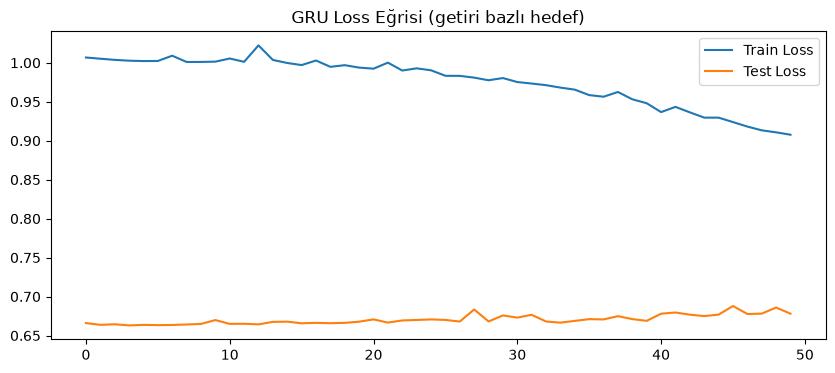

In [5]:

# --- Hücre 5: loss eğrisi ---
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("GRU Loss Eğrisi (getiri bazlı hedef)")
plt.show()

In [6]:

 
# --- Hücre 6: getiri tahminlerini fiyata çevir, MAE hesapla ---
model_gru.eval()
with torch.no_grad():
    device = next(model_gru.parameters()).device
    return_preds_scaled = model_gru(
        torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    ).cpu().numpy().flatten()
 
return_preds = y_scaler.inverse_transform(return_preds_scaled.reshape(-1, 1)).flatten()
 

In [7]:

# test setindeki gerçek kapanış fiyatları (window kaydırmasını hesaba katarak)
close_prices_test = test["close"].values[WINDOW:]
actual_next_prices = test["target"].values[WINDOW:]
 
predicted_next_prices = close_prices_test * (1 + return_preds)
 
mae_gru = mean_absolute_error(actual_next_prices, predicted_next_prices)
rmse_gru = np.sqrt(mean_squared_error(actual_next_prices, predicted_next_prices))
 
print(f"GRU (getiri bazlı) -> MAE: {mae_gru:.2f} $, RMSE: {rmse_gru:.2f} $")
print(f"Naive baseline MAE: 7.87 $ (karşılaştırma için)")
 

GRU (getiri bazlı) -> MAE: 8.00 $, RMSE: 12.25 $
Naive baseline MAE: 7.87 $ (karşılaştırma için)


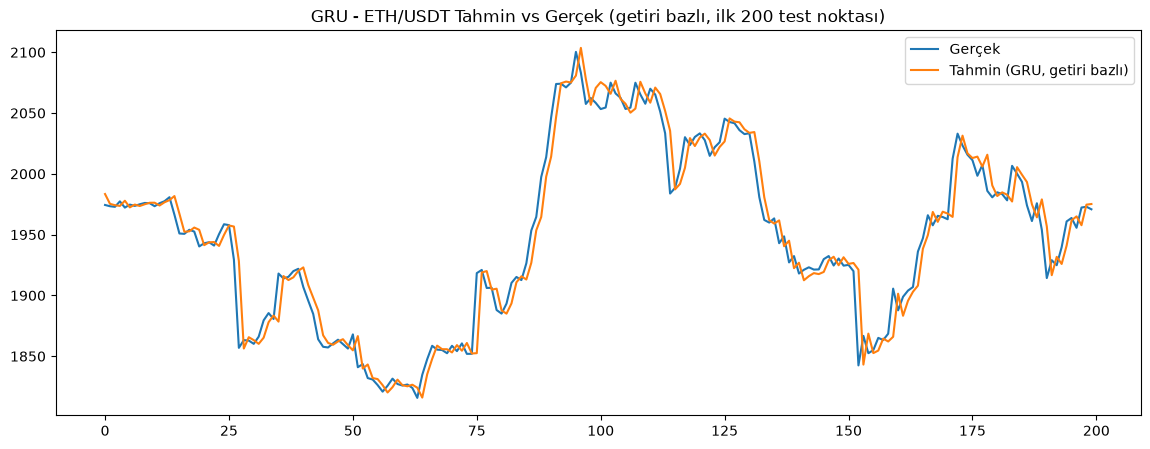

In [8]:

# --- Hücre 7: tahmin vs gerçek görselleştirme ---
plt.figure(figsize=(14, 5))
plt.plot(actual_next_prices[:200], label="Gerçek")
plt.plot(predicted_next_prices[:200], label="Tahmin (GRU, getiri bazlı)")
plt.legend()
plt.title("GRU - ETH/USDT Tahmin vs Gerçek (getiri bazlı, ilk 200 test noktası)")
plt.show()
 